In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [3]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost




In [4]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])


In [5]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state==self.goal


    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.
        legal_actions =[]
        row, col = state
        for action, (dr,dc) in MOVES.items():
          new_state = (row+dr, col+dc)

          if self.in_bounds(new_state) and self.is_free(new_state):
            legal_actions.append(action)

        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1



class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)

            yield Node(s_prime,node,action, cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass


In [6]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

In [7]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 1:
        # Return the cost of moving from state to next_state.
        #
        # Steps:
        # 1. Unpack next_state into row and col.
        row,col = next_state
        # 2. Return self.terrain_costs[row][col].
        return self.terrain_costs[row][col]


In [8]:
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")


WeightedGridProblem self-check passed.


In [9]:
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2:
    # Return the Manhattan distance between state and goal.
    #
    # Steps:
    # 1. Unpack state into (r1, c1) and goal into (r2, c2).
    r1,c1 = state
    r2,c2 = goal
    # 2. Return abs(r1 - r2) + abs(c1 - c2).
    return abs(r1 - r2) + abs(c1 - c2)


def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3:
    # Return the straight-line distance between state and goal.
    #
    r1,c1 = state
    r2,c2 = goal
    # Hint: math.sqrt(...) or math.dist(state, goal).
    return math.sqrt((r1 - r2)**2 + (c1 - c2)**2)


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0


In [10]:

assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


In [11]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

In [12]:
class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
        # TODO 4:
        # Implement the BEST-FIRST-SEARCH pseudocode above.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        initial_node = Node(problem.initial_state())
        # 2. Create a PriorityQueue frontier and push the initial node
        frontier = PriorityQueue()
        frontier.push(self.evaluation(initial_node,problem),initial_node)
        #    with priority self.evaluation(node, problem).
        # 3. Create a reached DICTIONARY mapping state -> Node, containing
        #    the initial state.
        reached = {initial_node.state: initial_node}

        # 4. Initialise counters: nodes_expanded = 0, max_frontier_size = 1.
        nodes_expanded = 0
        max_frontier_size = 1
        # 5. While the frontier is not empty:
        while frontier:
          node = frontier.pop()
          if problem.is_goal(node.state):
            return SearchResult(
                algorithm=self.algorithm_name,
                status="success",
                solution=node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=len(reached),
                limit=None,
                iterations=None
                                 )
          nodes_expanded+=1

          for child in self.expand(problem,node):
            s=child.state
            if s not in reached or child.path_cost < reached[s].path_cost:
              reached[s] = child
              frontier.push(self.evaluation(child, problem),child )

          max_frontier_size = max(max_frontier_size,len(frontier))

        return SearchResult(
            algorithm=self.algorithm_name,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
            limit=None,
            iterations=None)






        #       a. pop the node with the lowest f-value.
        #       b. if problem.is_goal(node.state): return a SearchResult with
        #          status "success" (use self.algorithm_name, nodes_expanded,
        #          max_frontier_size, and len(reached)).
        #       c. increment nodes_expanded.
        #       d. for each child in self.expand(problem, node):
        #             i. s = child.state
        #            ii. if s not in reached OR
        #                   child.path_cost < reached[s].path_cost:
        #                     reached[s] = child
        #                     push child with priority self.evaluation(child, problem)
        #       e. update max_frontier_size with len(frontier).
        # 6. If the loop ends, return a SearchResult with status "failure"
        #    and solution=None.


In [13]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 5:
        # Greedy Best-First Search: f(n) = h(n).
        # Hint: use self.h(node, problem).
        return self.h(node, problem)


In [14]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 6:
        # A* search: f(n) = g(n) + h(n).
        # Hint: g(n) is node.path_cost.
        return node.path_cost + self.h(node, problem)


In [15]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

In [16]:
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 7:
        # Weighted A*: f(n) = g(n) + W * h(n).
        return node.path_cost + (self.weight*self.h(node, problem))

In [17]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


In [18]:

sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,18,18,52,5,56
1,A*,success,18,18,18,5,23
2,Weighted A* (W=2),success,18,18,18,5,23
3,Greedy,success,18,18,18,5,23


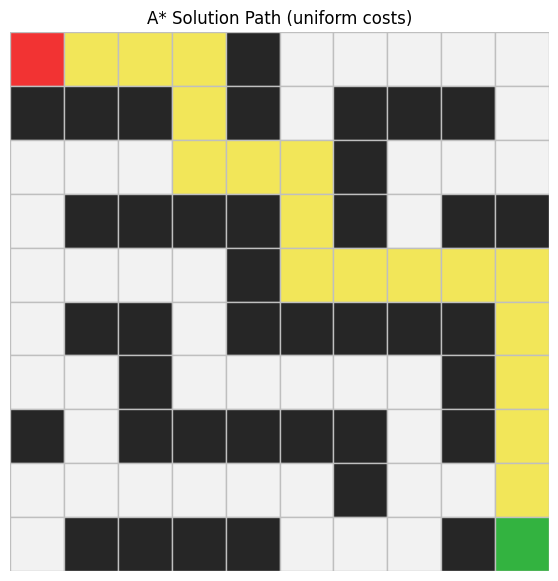

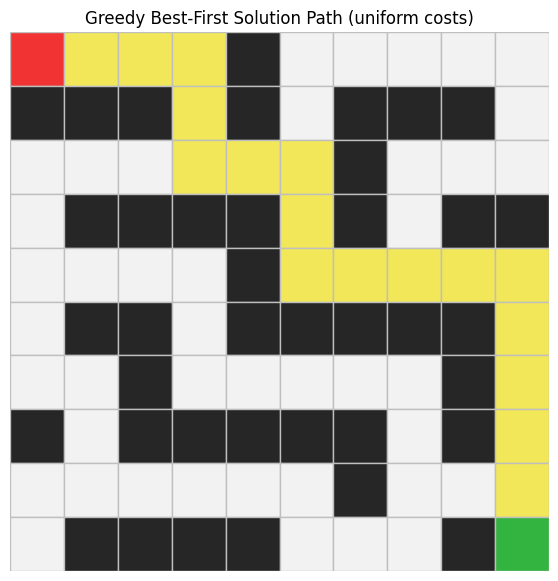

In [19]:
# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)


In [20]:

turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,12,35
1,A*,success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


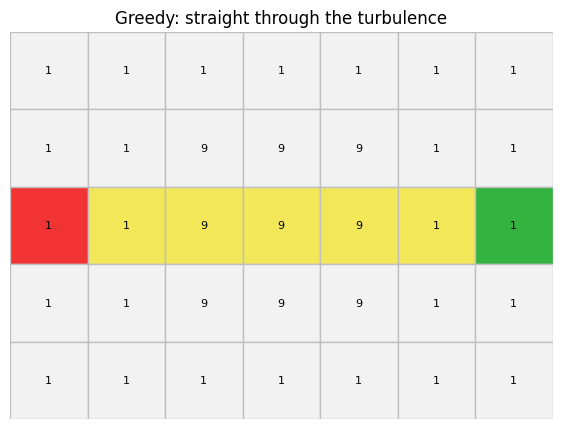

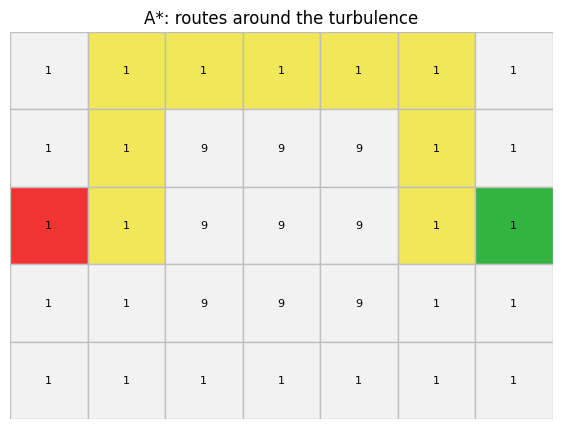

In [21]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

In [22]:
def inflated_heuristic(factor: float):
    # TODO 8:
    # Return a NEW heuristic function that overestimates by multiplying
    # Manhattan distance by `factor`.
    #
    # Steps:
    # 1. Define an inner function h(state, goal) that returns
    #    factor * manhattan_distance(state, goal).
    def h(state, goal):
      return factor * manhattan_distance(state, goal)
    # 2. Return the inner function (do not call it).
    #
    return h
    # Hint: this is a closure —
    # def h(state, goal):
    #     return ...
    # return h



# Once TODO 8 is complete, run the comparison.
#
# The "mild turbulence" map below is designed to expose the inflated
# heuristic: the direct route through the cost-3 band costs 12, while the
# calm detour costs 10. An overconfident heuristic charges straight ahead.

mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)




,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18,18,5,23
1,A* inflated x3 (uniform map),success,18,18,18,5,23
2,A* admissible (mild turbulence),success,10,10,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12,6,13,19


Record your observations in a markdown cell here:

1. On which map(s) did the inflated heuristic return a suboptimal path? By how much?
The inflated A* heuristic on the mild turbulence map returned a sub-optimal path. The solution cost is 12, and the optimal cost was found by the admissible A* search (mild turbulence). It was suboptimal by 2 units(12-10).

2. How many fewer nodes did it expand?

It expanded 23 fewer nodes. This is because the optimal search expanded 29 nodes, whereas the suboptimal, expanded 6 nodes.

3. In one or two sentences: when would you, as the drone's engineer, deliberately accept an inadmissible heuristic?

As the drone's engineer , I would accept the inadmissible heuristic when we are more concerned about speed as compared to finding the path with the smallest cost.

In [23]:
class IDAStarSearch(SearchAlgorithm):
    algorithm_name = "IDA*"

    def __init__(self, heuristic):
        self.heuristic = heuristic

    def search(self, problem: Problem, max_iterations: int = 200):
        # TODO 9 (BONUS, optional):
        # Implement IDA* following the pseudocode guide above.
        #
        # Requirements:
        # 1. Start with limit = h(initial state).
        start = Node(problem.initial_state())
        limit = self.heuristic(start.state, problem.goal)



       # 2. Each iteration performs a recursive f-limited depth-first search
       #    that uses path-cycle checking (reuse the idea from DLS in Part A:
       #    skip a child whose state already appears on the current path).



       # 3. Track total nodes_expanded across all iterations and the maximum
        #    recursion depth as max_frontier_size.
        nodes_expanded = 0
        max_depth = 0
        iterations = []


        def f(node):
            return node.path_cost + self.heuristic(node.state, problem.goal)


        def dfs(node, limit, path):

            nonlocal nodes_expanded, max_depth

            nodes_expanded += 1
            max_depth = max(max_depth, len(path))

            fn = f(node)

            if fn > limit:
                return None, fn

            if problem.is_goal(node.state):
                return node, fn

            next_limit = float("inf")

            for child in self.expand(problem, node):


                if child.state in path:
                    continue

                result, new_limit = dfs(child, limit, path | {child.state})

                if result is not None:
                    return result, new_limit

                next_limit = min(next_limit, new_limit)

            return None, next_limit


        for i in range(max_iterations):

            result, new_limit = dfs(start, limit, {start.state})
# 4. Keep an iteration log of (limit, outcome) pairs in
        #    SearchResult.iterations.
            iterations.append({
                "limit": limit,
                "outcome": "success" if result else f"next_limit={new_limit}"
                })


        # 5. Return status "success", "failure" (next limit is infinity), or
        #    "cutoff" (max_iterations reached).

            if result is not None:
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=result,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_depth,
                    reached_count=0,
                    limit=limit,
                    iterations=iterations
                )

            if new_limit == float("inf"):
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="failure",
                    solution=None,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_depth,
                    reached_count=0,
                    limit=limit,
                    iterations=iterations
                )

            limit = new_limit

        return SearchResult(
            algorithm=self.algorithm_name,
            status="cutoff",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_depth,
            reached_count=0,
            limit=limit,
            iterations=iterations
        )


        # After completing the bonus, compare IDA* with A* here:
ida = IDAStarSearch(manhattan_distance)
show_results([astar.search(uniform_problem), ida.search(uniform_problem)])

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A*,success,18,18,18,5,23
1,IDA*,success,18,18,22,19,0


In [24]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0]
]

custom_costs_1 = [
    [1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1],
    [1,1,8,8,8,8,8,1,1,1],
    [1,1,8,8,8,8,8,1,1,1],
    [1,1,8,8,8,8,8,1,1,1],
    [1,1,8,8,8,8,8,1,1,1],
    [1,1,8,8,8,8,8,1,1,1],
    [1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1]
]

custom_start_1 = (4,0)
custom_goal_1 = (4,9)

# Example after completing:
custom_problem_1 = WeightedGridProblem(
     custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
 )
custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1), ]

show_results(custom_results_1)




,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,15,15,83,22,96
1,A*,success,15,15,44,41,81
2,Weighted A* (W=2),success,15,15,24,27,51
3,Greedy,success,9,44,9,19,28


For Custom map 1, A*, Weighted A* and UCS found the optimal path with the lowest cost of 15. On the metric of nodes expanded, UCS expanded the most nodes, followed by A8 and then weighted A* with the lowest expanded nost among the searches that got the optimal cost.

Greedy BFS , although having the lowest solution depth and nodes expanded, had the highest cost. So if we want to obtain the goal as fast as possible, without caring for the cost, we can use the Greedy Best First Search.

To summarise, Greedy BFS wins if we only care for the shortest path, however for optimality , we would go for the Weighted A* Search.

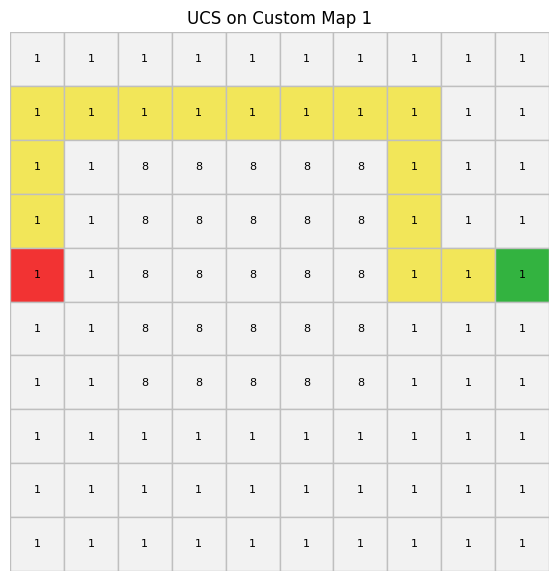

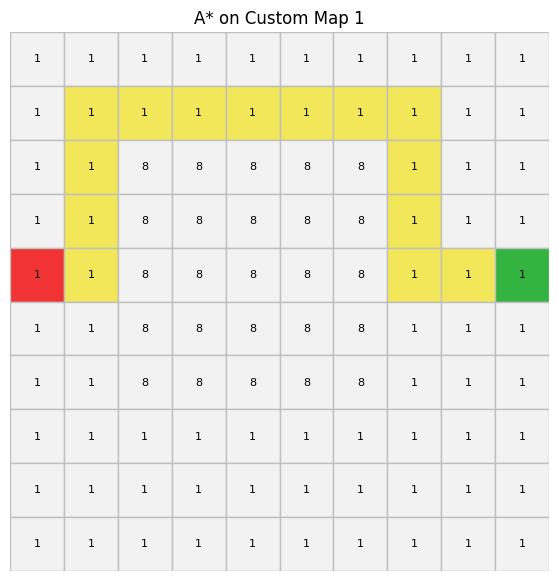

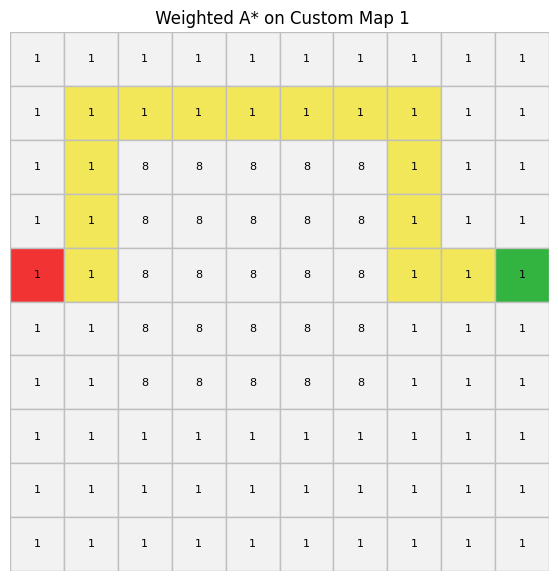

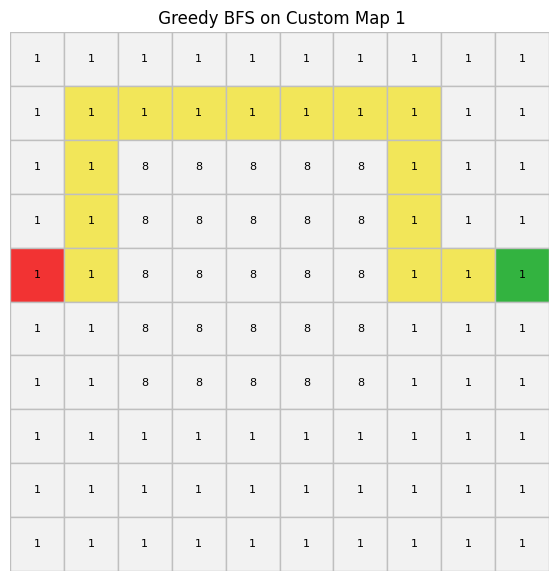

In [25]:
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[0].path,
    terrain_costs=custom_costs_1,
    title="UCS on Custom Map 1",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[1].path,
    terrain_costs=custom_costs_1,
    title="A* on Custom Map 1"
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[1].path,
    terrain_costs=custom_costs_1,
    title=" Weighted A* on Custom Map 1"
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[2].path,
    terrain_costs=custom_costs_1,
    title=" Greedy BFS on Custom Map 1"
)

In [26]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0]
]

custom_costs_2 = [
[1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,9,9,9,9,9,1,1],
[1,1,1,1,9,9,9,9,9,1,1],
[1,1,1,1,9,9,9,9,9,1,1],
[1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1],
[1,1,1,1,1,1,1,1,1,1,1]
]

custom_start_2 = (5,0)
custom_goal_2 = (5,10)

# Example after completing:
custom_problem_2 = WeightedGridProblem(
  custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
 )
custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
 ]
show_results(custom_results_2)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,14,14,104,22,118
1,A*,success,14,14,39,37,74
2,Weighted A* (W=2),success,14,14,21,26,47
3,Greedy,success,10,50,10,21,31


For the Custom map 2, I would say the Weighted A* search won. Using soluion cost, the A*, Weighted A* and UCS found the optimal path which has a solution cost of 14,however, the greedy BFS has a solution cost of 50 although it has the lowest depth(10). As usual, the Greedy BFS expanded the least nodes but at the highest cost, meaning a suboptimal result. The Weighted A* expanded the second least number of nodes, and still maintained the optimal cost of 14. The other searches which acheived the solution cost of 14, expanded more nodes than the Weighted A* search. This means the Weighted A* search provided efficiency and optimality.

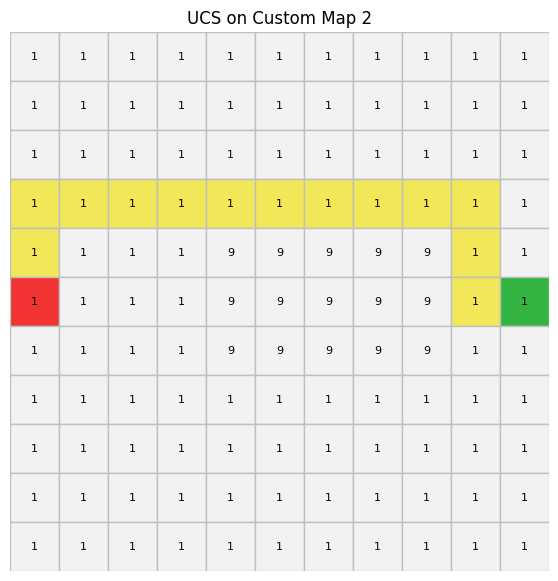

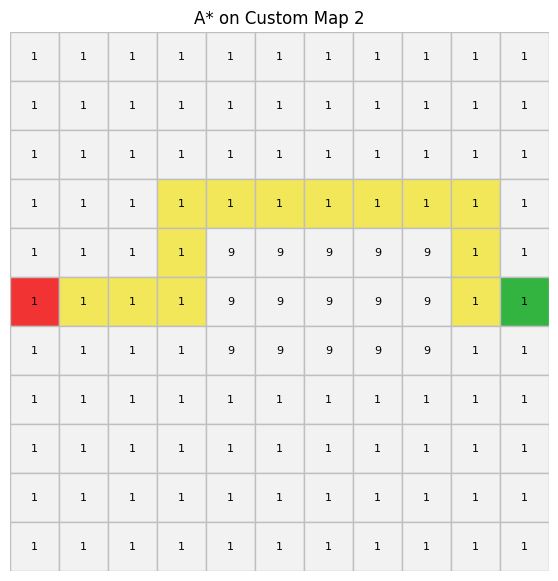

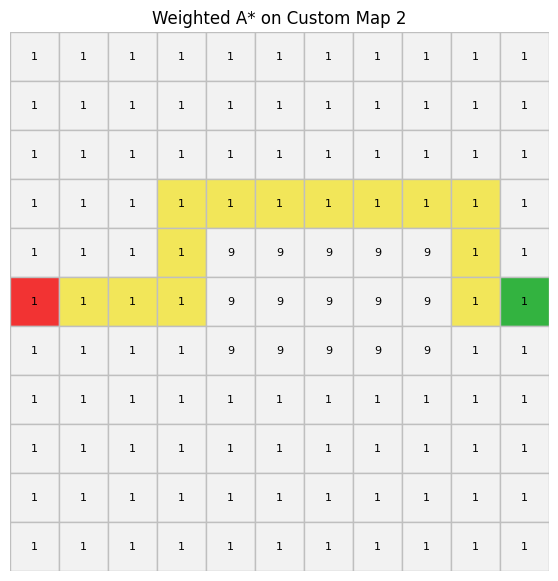

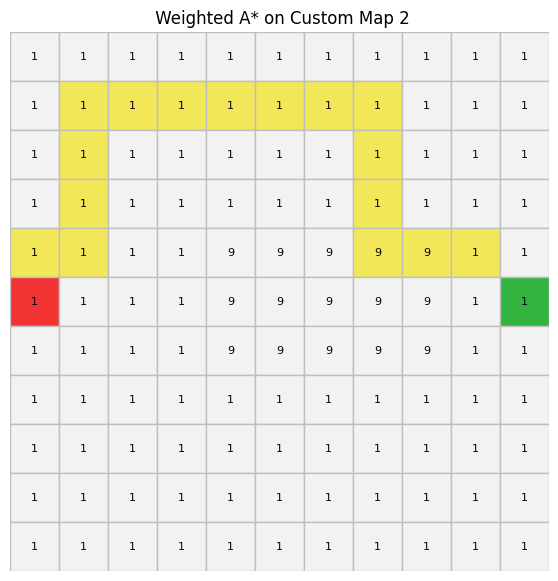

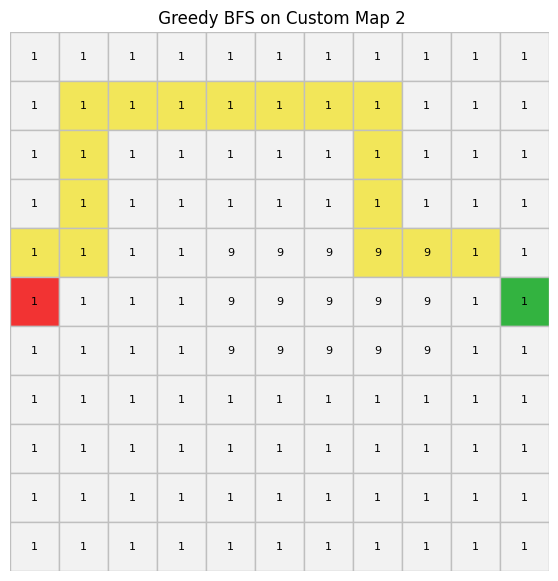

In [27]:
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[0].path,
    terrain_costs=custom_costs_2,
    title="UCS on Custom Map 2",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[1].path,
    terrain_costs=custom_costs_2,
    title="A* on Custom Map 2"
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[2].path,
    terrain_costs=custom_costs_2,
    title="Weighted A* on Custom Map 2"
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_1[1].path,
    terrain_costs=custom_costs_2,
    title=" Weighted A* on Custom Map 2"
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_1[2].path,
    terrain_costs=custom_costs_2,
    title=" Greedy BFS on Custom Map 2"
)

**16.1 Heuristic Functions**


1. In your own words, what does h(n) estimate, and where does its "knowledge" come from in this lab?

It estimates the cost from a certain node n to the goal. In this lab, we get information about the heuristic estimate from the grid we are given , including the positions of the current state and the goal.


2. Manhattan distance is the exact solution cost of a relaxed problem. Which restrictions of the original drone problem does that relaxation remove?

Obstacles and terrain costs are removed in the relaxed problem, becuase the Manhattan distance pretends like it does not exist. In this, the drone moves across the grid freely and every move has a uniform cost.


3. Both Manhattan and Euclidean distance are admissible on our grid. Which one dominates the other, and what does domination predict about nodes expanded?

I think the Manhattan distance dominates the Euclidean distance. This is because we can observe that the estimate it gives is larger and it is till admissible at the same time. A dominating heuristic is one that provides more information to help guide the search.


4. Why does requiring all terrain costs to be ≥ 1 keep Manhattan distance admissible on the weighted maps? What could go wrong with a terrain cost of 0.5?

Manhattan distance counts moves and not costs and so a terrain cost >=1, would still use the same number of moves.

**16.2 Greedy Best-First Search**


1. Which quantity does Greedy ignore, and how did the turbulence map punish it for that?

The Greedy Best First Search ignores the accumulated path cost, which is g(n) and only considers the heuristic function h(n). The turbulence map punishes it for this by increasing the cost of its direct route, which appears closest to the goal.So the search would reach quickly but pay an expensive price to do so, as compared to the other searches like UCS and A*.


2. Greedy expanded fewer nodes than A* on some maps. Why is that not enough to call it the better algorithm?

As the Greedy BFS is faster, it is expected to expand less number of nodes compared to the other searches. However, this comes at the sacrifice of the solution cost, which most times, is much higher than the A* search which expands more nodes. Additionally, the A* ensures optimal solution when the heuristic is admissible. So although it expands less nodes, this speed sacrifices quality, which is why it is not the better algorithm.


3. Describe a drone mission where Greedy's behaviour would actually be acceptable.

Such a drone mission would occur where time taken is more important, or a route is needed immediately.A real life example, could be a health emergency delivery,i.e. antivenom, defibrillators, inhalers etc, which would be needed in the fastest possible time, not really caring for the cheapest path.  

16.3 A* Search

1. Explain f(n) = g(n) + h(n) as a sentence about the drone's flight plan.

The evaluation cost,f(n), indicates the sum of the path cost already spent by the drone and the estimated cost. Therefore, the total trip estimate would be the distance the drone has travelled so far addded to the remaining distance to the drone's destination.

2. Why must A* apply the goal test when a node is popped rather than when it is generated? What could go wrong with an early goal test on the turbulence map?

It does this so that the solution path remains optimal .A* applies the goal test when a node is popped because the generated node may not be the cheapest node available, and so if we apply the goal test after generation, we may miss the optimal path. Therefore, it prevents the risk of an expensive path.

3. Why does reached need to be a dictionary (state → best node) in this lab, when a plain set was enough for BFS in Part A?

This is because in A* search , the costs of the paths are not the same. In BFS , we assume all moves cost the same, and so we can use a plain set.  The dictionary allows to track the cheapest cost found as we move to the next state, which is vital for finding optimal cost in this A* search.


4. Compare the nodes expanded by UCS and A* on the sample map. What does this gap tell you about the value of the heuristic?


For my custom map 2, the nodes expanded for UCS is 104 and that of the A* search is 39,which is 65 less nodes for the A* search algorithm. From the function for UCS, which uses just the path cost, i.e., g(n), this is expected. This gap tells us that the heuristic estimate was very important and helped us to explore less while still finding the optimal solution. The gap also determines how much of a difference the heuristic estimate made in helping the search algorithm to find the goal.



**16.4 Admissibility and Consistency**

1. State the definitions of admissible and consistent. Which implies which?

Admissible means that the heuristic estimate is not overstimated. That is, h(n)<=h*(n).
Consistent means that for ever move, h(n)<=c(n,a,n') + h(n'). This means that the h(n) cannot become less than the actual cost of that move.
We also learnt that every consistent heuristic is admissible but not everyadmissible heuristic is consistent.

2. What did your inadmissible-heuristic experiment show about the lecture's optimality claim?

Our experiment affirms what the lecturer stated. This is because


3. Is Manhattan distance consistent on our unit-cost grid? Check the triangle inequality h(n) ≤ c(n, a, n') + h(n') for a single move and explain.

Assume start = (0,0)
goal=(9,9)
Manhattan distance,h(0,0) = |9-0| + |9-0|= 18.

If we move right,
h(0,1) = |9-0| + |9-1|= 17

We now check consistency with h(n) ≤ c(n, a, n') + h(n')
Unit cost grid has c(n, a, n')=1
18 <= 1+ 17 is true.

Yes, the Manhattan distance is consistent on our unit-cost grid.This is because a single move changes the Manhattan distance by 1 or less, whilst the cost is still 1.

16.5 Weighted A* and Trade-offs

1. How does the weight W interpolate between UCS, A*, and Greedy?

In UCS, the weight is 0. In A*, the weight is a constant 1 and in Greedy BFS the weight is a a larger number. The larger the weight, the more greedy the search algorithm would be.

2. What suboptimality bound does Weighted A* guarantee, and did your experiments stay well inside that bound?

Weighted A* guarantees that the solution cost < = Weight x Optimal cost. Yes, my experiments saty withing the bound. Looking at the custom map 2, Optimality was at a solution cost of 14, and the Weighted A* had that solution cost. This falls inside the bound once calculated.

3. The drone has 90 seconds of battery margin and the flight computer is slow. Which algorithm and which W would you choose, and why?

I would choose the weighted A* search, and have my weight as 2. My experiments as well as other maps show that it expands slightly fewer nodes than the UCS and A*. In addition, it finds the optimal path also. Due to the slow flight computer and 90 second battery margin, we must aim to reduce the amount of time used to compute for the goal. The weighted A8 brings on some suboptimality as we saw earlier, however, it is a good risk to take comsidering this drone's situation.